# M4 — Validation: the Inelastic Prototype Passes its Gate

**Inelastic coding prompt 5, task 4** (2026-08-27). M4 ran the design-§6
validation protocol over the complete corrected forward model —
`Rrs = (Rrs_ZTT + ΔRrs) · f_R + φ_C·K_fl(1 + δ_F)` with the committed
129-parameter heads — and **all six gate lines pass** (record §6.6; the
task-3 review pass is §6.7): held-out total rRMS vs the all-processes-on
`Rrs_X4` ≤ 0.5 % at every zenith over the model's **400–700 nm** domain
(the gate band is JXP's call, prompt 5 Q&A Q1); per-process deltas ≤ 5 %
including the 0° line the analytic backbone failed by −38.6 %;
`inelastic=None` bit-identical to the elastic hybrid; gradients ≤ 1e-6 for
all six inputs including φ_C; and the full-batch forward at **1.59×** the
elastic hybrid's cost against a ≤ 2× budget (it entered M4 at 6.3×).

Everything below recomputes from the committed weights on the full release
and is **cross-checked programmatically against the committed artifacts**
(`design/validation/metrics_inelastic.csv`, regenerable by one command:
`python design/py/run_validation.py --inelastic`) — no number is
transcribed. §4 states what the prototype may claim and the five measured
reasons to be careful with it.

In [1]:
import csv
import sys
from pathlib import Path

REPO = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'robust' / '__init__.py').exists())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

import jax
import jax.numpy as jnp
import numpy as np

from robust.rt import conventions as C
from robust.rt import emulator as E
from robust.rt import hybrid as H
from robust.rt import inelastic as I
from robust.rt import inelastic_corr as IC
from robust.rt import validation as V
from robust.rt.data import l23 as L
from robust.rt.types import Inelastic

em = E.load_default()      # eager, before anything jits (record §6.4)
batch = L.load_inelastic_batch()          # the full release ($OS_COLOR)
splits = L.make_splits(batch)             # the elastic splits, verbatim
heads = IC.load_default()                 # the committed weights
args = (batch.iops, batch.phase_params, batch.geometry, batch.wave)
wave = np.asarray(batch.wave)
zen = batch.zenith
held = splits.scene_test
lo, hi = V.INELASTIC_GATE_BAND
band = (wave >= lo) & (wave <= hi)
truth = np.asarray(C.Rrs_to_rrs(batch.Rrs_x4))

models = {
    'elastic-only': H.rrs_forward(*args, 'hybrid', emulator=em,
                                  check_domain=False),
    'analytic inelastic': H.rrs_forward(*args, 'hybrid',
                                        inelastic=Inelastic(),
                                        corrections=False, emulator=em,
                                        check_domain=False),
    'corrected inelastic': H.rrs_forward(*args, 'hybrid',
                                         inelastic=Inelastic(),
                                         corrections=heads, emulator=em,
                                         check_domain=False),
}
models = {k: np.asarray(v) for k, v in models.items()}
gate_rrms = {k: V.group_rrms(jnp.asarray(truth[held][:, band]),
                             jnp.asarray(v[held][:, band]), zen[held])
             for k, v in models.items()}
full_rrms = {k: V.group_rrms(jnp.asarray(truth[held]),
                             jnp.asarray(v[held]), zen[held])
             for k, v in models.items()}

# The committed artifacts, and the no-transcription rule: every headline
# number this notebook shows must match what one command regenerates.
committed = {}
with open(REPO / 'design/validation/metrics_inelastic.csv') as fh:
    for row in csv.DictReader(fh):
        committed[(row['section'], row['metric'], row['zenith'])] = row['value']
for z in (0.0, 30.0, 60.0):
    key = ('total_rrms', f'corrected inelastic {lo:.0f}-{hi:.0f}nm', f'{z:.0f}')
    assert abs(gate_rrms['corrected inelastic'][z] - float(committed[key])) < 1e-3
committed_speed = float(committed[('speed', 'median_ratio', '')])

print(f'repo: {REPO}; jax {jax.__version__} on {jax.default_backend()}')
print(f'full release: {batch.n_sample} samples; {int(held.sum())} held-out; '
      f'gate band {lo:.0f}-{hi:.0f} nm (Q&A Q1)')
print('recomputed == committed artifacts for the gate-band totals: OK')

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


repo: /mnt/tank/Oceanography/python/retrieve-or-bust; jax 0.11.1 on cpu
full release: 9960 samples; 1992 held-out; gate band 400-700 nm (Q&A Q1)
recomputed == committed artifacts for the gate-band totals: OK


## 1. The total-rRMS ladder — what each layer of the model buys

Per-wavelength rRMS vs `Rrs_X4` on held-out scenes. The **elastic-only
baseline** is the cost of ignoring inelastic physics against an ocean that
has it: ~5 % in the blue rising to ~15 % through the Raman-dominated red and
**~48 % at the 685 nm fluorescence peak**. The **analytic backbone** (M2's
fixed-BING port with the true Ed) closes most of that; the **committed
heads** flatten the rest to a median 0.33 % — under the 0.5 % gate at every
zenith on the 400–700 nm domain.

The shaded regions are *ungated, deliberately visible*: below 400 nm the
Raman excitation leaves the L23 grid and clamps and the heads never trained
(13 % at 350 nm — the cliff is why JXP set the gate band); above 700 nm the
gate band ends but the model stays close. The per-λ line may cross 0.5 %
(450 nm, the 685 nm band) — the *gate* is the per-zenith total, which
absorbs those excursions.

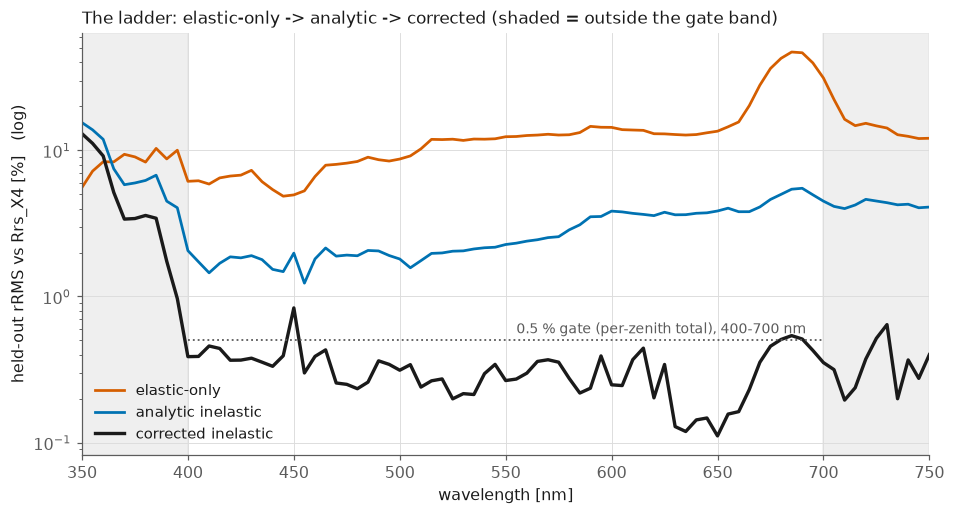

held-out total rRMS vs Rrs_X4 [%], 400-700 nm (full 350-750 grid in parentheses):
  elastic-only         0deg 18.715 (17.85)  30deg 15.799 (14.67)  60deg 16.339 (15.15)
  analytic inelastic   0deg  4.294 ( 5.20)  30deg  1.941 ( 3.74)  60deg  2.178 ( 4.04)
  corrected inelastic  0deg  0.343 ( 2.61)  30deg  0.341 ( 2.27)  60deg  0.340 ( 2.28)


In [2]:
import matplotlib as mpl
import matplotlib.pyplot as plt

INK, INK_MUTED, GRID = '#1a1a1a', '#5c5c5c', '#dcdcdc'
C_A, C_B, MUTED = '#0072B2', '#D55E00', '#9a9a9a'
mpl.rcParams.update({
    'figure.dpi': 110, 'font.size': 10.5, 'axes.edgecolor': INK_MUTED,
    'axes.labelcolor': INK, 'text.color': INK, 'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED, 'axes.spines.top': False,
    'axes.spines.right': False, 'axes.grid': True, 'grid.color': GRID,
    'grid.linewidth': 0.6, 'legend.frameon': False,
})

ladders = {k: np.asarray(V.rrms_per_wavelength(
    jnp.asarray(truth[held]), jnp.asarray(v[held]))) for k, v in models.items()}

fig, ax = plt.subplots(figsize=(8.8, 4.8))
for name, colour, width in (('elastic-only', C_B, 1.8),
                            ('analytic inelastic', C_A, 1.8),
                            ('corrected inelastic', INK, 2.2)):
    ax.plot(wave, ladders[name], color=colour, lw=width, label=name)
ax.set_yscale('log')
ax.set_xlim(wave.min(), wave.max())
ax.axvspan(wave.min(), lo, color=GRID, alpha=0.45, zorder=0)
ax.axvspan(hi, wave.max(), color=GRID, alpha=0.45, zorder=0)
bar = V.INELASTIC_GATE_TOTAL_RRMS
ax.plot([lo, hi], [bar, bar], color=INK_MUTED, lw=1.2, ls=':')
ax.annotate(f'{bar:g} % gate (per-zenith total), {lo:.0f}-{hi:.0f} nm',
            xy=(hi - 8, bar * 1.12), ha='right', fontsize=9, color=INK_MUTED)
ax.set_xlabel('wavelength [nm]')
ax.set_ylabel('held-out rRMS vs Rrs_X4 [%]   (log)')
ax.legend(loc='lower left', fontsize=9.5)
ax.set_title('The ladder: elastic-only -> analytic -> corrected '
             '(shaded = outside the gate band)', loc='left', fontsize=11)
fig.tight_layout()
plt.show()

print(f'held-out total rRMS vs Rrs_X4 [%], {lo:.0f}-{hi:.0f} nm '
      '(full 350-750 grid in parentheses):')
for name in models:
    g, f = gate_rrms[name], full_rrms[name]
    print(f'  {name:20s} ' + '  '.join(
        f'{z:.0f}deg {g[z]:6.3f} ({f[z]:5.2f})' for z in (0.0, 30.0, 60.0)))

## 2. The per-process gates — what the heads closed, held out

The design gates each process against its own exact truth channel: the
Raman factor against `Rrs_X2/Rrs_X1` on the *increment* (a ratio of factors
would hide a −39 % error inside 1 + small), fluorescence against
`Rrs_X4 − Rrs_X2` at its 685 nm peak. Grey dots are the analytic backbone,
black the committed heads; the band is the ±5 % gate. The headline is the
top row: the analytic −38.6 % at high sun — the assessment's worst line,
inherited from the S&P98 two-flow approximations — sits at **−0.14 %**
corrected. Every number is the shared
`validation.median_increment_error` / `peak_ratio_error` definition, the
same functions the gate tests assert.

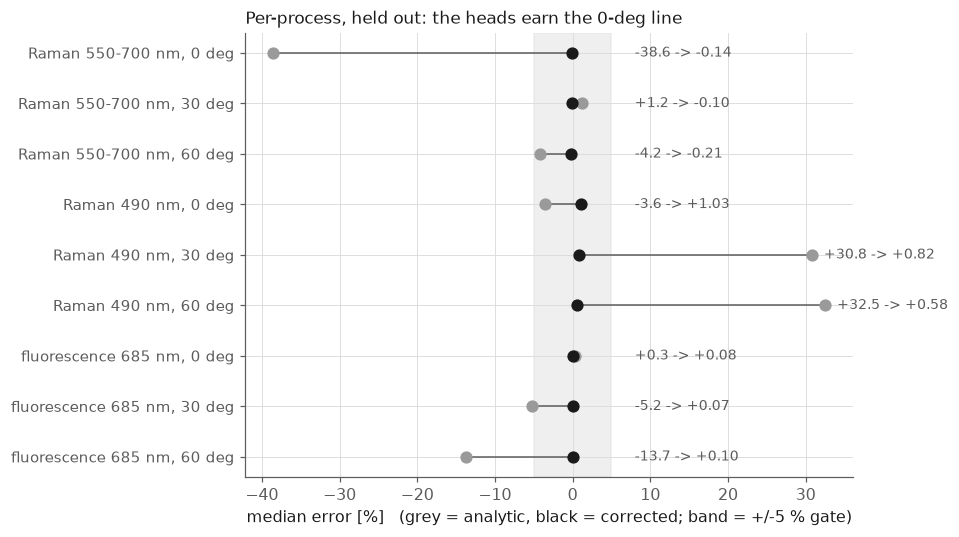

In [3]:
f_phys = np.asarray(I.raman_factor(batch.iops, batch.geometry, batch.wave))
d_r = np.asarray(heads.raman.delta(batch.iops, batch.geometry, batch.wave))
f_corr = np.asarray(IC.corrected_raman_factor(d_r, f_phys))
f_truth = np.asarray(batch.truth_raman_factor)
k_fl = np.asarray(I.fluorescence_kernel(batch.iops, batch.geometry,
                                        batch.wave))
d_f = np.asarray(heads.fl.delta(batch.iops, batch.geometry, batch.wave))
fl_corr = L.PHI_C_L23 * np.asarray(IC.corrected_fluorescence(d_f, k_fl))
fl_analytic = L.PHI_C_L23 * k_fl
fl_truth = np.asarray(batch.truth_fluorescence)
i685 = int(np.abs(wave - 685.0).argmin())

zeniths = (0.0, 30.0, 60.0)
deltas = {}
for label, cols in (('Raman 550-700 nm', (wave >= 550.0) & (wave <= 700.0)),
                    ('Raman 490 nm', np.abs(wave - 490.0) < 1e-6)):
    a = V.median_increment_error(f_phys[held], f_truth[held], zen[held], cols)
    c = V.median_increment_error(f_corr[held], f_truth[held], zen[held], cols)
    deltas[label] = {z: (a[z], c[z]) for z in zeniths}
fa = V.peak_ratio_error(fl_analytic[held], fl_truth[held], zen[held], i685)
fc = V.peak_ratio_error(fl_corr[held], fl_truth[held], zen[held], i685)
deltas['fluorescence 685 nm'] = {z: (fa[z], fc[z]) for z in zeniths}

rows = [(f'{label}, {z:.0f} deg', 100 * deltas[label][z][0],
         100 * deltas[label][z][1]) for label in deltas for z in zeniths]
fig, ax = plt.subplots(figsize=(8.8, 5.0))
gate_pct = 100 * V.INELASTIC_GATE_DELTA
ax.axvspan(-gate_pct, gate_pct, color=GRID, alpha=0.45, zorder=0)
for y, (label, a, c) in enumerate(rows):
    ax.plot([a, c], [y, y], color=INK_MUTED, lw=1.0, zorder=2)
    ax.plot([a], [y], 'o', color=MUTED, ms=7, zorder=3)
    ax.plot([c], [y], 'o', color=INK, ms=7, zorder=4)
    ax.annotate(f'{a:+.1f} -> {c:+.2f}', xy=(max(a, 6.5) + 1.5, y),
                va='center', fontsize=9, color=INK_MUTED)
ax.set_yticks(range(len(rows)), [r[0] for r in rows], fontsize=9.5)
ax.invert_yaxis()
ax.set_xlabel(f'median error [%]   (grey = analytic, black = corrected; '
              f'band = +/-{gate_pct:g} % gate)')
ax.set_title('Per-process, held out: the heads earn the 0-deg line',
             loc='left', fontsize=11)
fig.tight_layout()
plt.show()

## 3. Speed and gradients — the other two gate lines, re-verified live

The speed gate is a *ratio* on this machine (wall-clock wanders ~±5 %
between trials, so the gate test asserts a **median** of alternating-order,
compile-once trials); the committed artifact number is 1.59×, and the cell
prints what this run measures beside it. It entered M4 at **6.3×** — the
fluorescence kernel's `(batch, 81, 65)` quadrature and an XLA consumer-fusion
pathology that re-ran the whole 52M-element reduction once per downstream
use — and left at ~1.6× via three algebraically-identical rewrites
(record §6.4), the largest bit-identical.

The gradient line is the property the future inversion buys everything else
for: `jax.grad` against central finite differences, float64, per-variable
steps, through the composed corrected forward — all six inputs including
`a_ph` (the fluorescence source) and `φ_C` (the physiology handle),
evaluated at θ_s = 35°, off the packaged-Ed anchors where the θ_s-derivative
is one-sided (record §4.4).

In [4]:
@jax.jit
def corrected_fn(i, p, g, w):
    return H.forward(i, p, g, w, 'hybrid', inelastic=Inelastic(),
                     corrections=heads, emulator=em, check_domain=False)

@jax.jit
def elastic_fn(i, p, g, w):
    return H.forward(i, p, g, w, 'hybrid', emulator=em, check_domain=False)

trials = [V.speed_ratio(corrected_fn, elastic_fn, *args, repeats=10,
                        reverse=bool(t % 2)) for t in range(3)]
ratio = float(np.median([t[0] for t in trials]))
print(f'speed: {1e3 * np.median([t[1] for t in trials]):.1f} ms inelastic / '
      f'{1e3 * np.median([t[2] for t in trials]):.1f} ms elastic = '
      f'{ratio:.2f}x median (this run; committed artifact: '
      f'{committed_speed:.2f}x; gate <= {V.INELASTIC_GATE_SPEED:g}x)')
assert ratio <= V.INELASTIC_GATE_SPEED

jax.config.update('jax_enable_x64', True)
try:
    rows64 = np.where(zen == 30)[0][:3]
    f64 = lambda x: jnp.asarray(np.asarray(x)[rows64], dtype=jnp.float64)
    from robust.rt.types import Geometry, IOPs, PhaseParams
    report = V.inelastic_gradient_report(
        lambda i, p, g, w, phi: H.forward(
            i, p, g, w, 'hybrid', inelastic=Inelastic(phi_C=phi),
            corrections=heads, emulator=em, check_domain=False),
        IOPs(a=f64(batch.iops.a), bb_w=f64(batch.iops.bb_w),
             bb_p=f64(batch.iops.bb_p), a_ph=f64(batch.iops.a_ph)),
        PhaseParams(B_p=f64(batch.phase_params.B_p)),
        Geometry.nadir(jnp.full((3,), 35.0, dtype=jnp.float64)),
        jnp.asarray(wave, dtype=jnp.float64),
        phi_C=jnp.asarray(L.PHI_C_L23, jnp.float64))
finally:
    jax.config.update('jax_enable_x64', False)

print('\ngradients (jax.grad vs central FD, float64, theta_s = 35 deg):')
for name in V.INELASTIC_FD_STEPS:
    print(f'  d/d{name:8s} {report[name]:.1e}')
assert all(v <= V.GRADIENT_TOL for v in report.values())

omitted = np.asarray(C.rrs_to_Rrs(jnp.asarray(models['elastic-only'])))
explicit = np.asarray(H.forward(*args, inelastic=None, emulator=em,
                                check_domain=False))
print(f'\ninelastic=None bit-identical to the elastic hybrid: '
      f'{np.array_equal(omitted, explicit)}')

speed: 56.2 ms inelastic / 32.4 ms elastic = 1.71x median (this run; committed artifact: 1.59x; gate <= 2x)



gradients (jax.grad vs central FD, float64, theta_s = 35 deg):
  d/da        2.5e-09
  d/dbb_p     3.6e-10
  d/dB_p      1.9e-09
  d/da_ph     5.9e-09
  d/dphi_C    1.4e-09
  d/dtheta_s  3.0e-09

inelastic=None bit-identical to the elastic hybrid: True


## 4. What the prototype may claim — and the five measured reasons for care

**The claim** (design's definition of done, coding plan): `forward(iops,
phase_params, geometry, wave, inelastic=Inelastic())` reproduces the
all-processes-on L23 ocean to **≤ 0.5 % held-out rRMS at every zenith** over
its 400–700 nm domain, with per-process deltas ≤ 5 % *including Raman at
high sun*, leaves elastic-only behavior **bit-identical**, is differentiable
in everything including φ_C to ≤ 1e-6, and runs within **1.6×** of the
elastic hybrid — with committed weights, a committed metrics table + figures
regenerable by one command, and this record. **The M4 gate passes; the
inelastic prototype is done.**

**The caveats are measured, not hypothetical** (record §§4–6 — carried
verbatim, as the elastic `prototype_summary.md` candor rule requires):

1. **The 3-zenith geometry cliff.** The heads are interpolators in
   cos θ_s over exactly three suns: a δ_R trained without 60° errs by
   **−74 %** there — *worse than no correction at all* (notebook 4 §3).
   Unseen geometries need training coverage or a domain guard.
2. **φ_C-linearity has truth only at 0.02.** The model is φ_C-linear by
   construction (δ_F has no yield column; verified to <1e-4 across
   0.5–5× scales), but HydroLight ran one yield — linearity is a design
   *bet*, not a validated fact, away from 0.02.
3. **`emission_shape='double'` is unvalidatable.** The PS I shoulder moves
   the 685 nm line by −8.5 % and 730 nm by +9.8 %; against the
   single-shape truth it scores −23.6 %. Physically better, invisible to
   L23, off everywhere in v1.
4. **λ ≥ 400 nm only.** Below 400 nm the Raman excitation leaves the L23
   grid and clamps and the heads never trained: 13 % rRMS at 350 nm. The
   gate band (Q&A Q1) reflects the domain; the full-grid numbers are in
   the committed table.
5. **The θ_s-derivative is one-sided at 0/30/60°.** The packaged Ed is
   piecewise-linear with anchors at the three suns, so autodiff at an
   anchor returns a one-sided slope (record §4.4). Differentiate off the
   anchors — every gate does, at 35°.

Plus the elastic inheritances: nadir view, L23-like water, and the narrow
`B_p` slice (§ elastic record). Next steps live in
`claude_prompts/RT/rt_inelastic_prompts.md` and the coding plan's
"Beyond v1" (the HydroLight wishlist: denser zeniths, varied φ_C, off-nadir
views — each turns one caveat above into a testable gate).

**Branch state for the PR**: everything M0–M4 is on `inelastic-rt`
(prompt 1 Q&A Q2 kept it over the plan's `rt-inelastic-prototype`), suite
**431 passed, 1 skipped**, ruff + format clean, elastic hash pins green,
artifacts committed and regenerable. Ready for JXP's M4 PR and the
`@cursor review` round.